<a href="https://colab.research.google.com/github/AP6-coder/Data_Profiling/blob/main/Face_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Stap 1: Datasetvoorbereiding

In [ ]:
# 1a. Laballed Faces in the Wild dataset uploaden

In [2]:
# kaggle package
!pip install -q kaggle

In [ ]:
# upload kaggle.json bestand
from google.colab import files
files.upload()

In [4]:
# Zet het bestand op de juiste plek
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [5]:
# aanpassen van permission
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
# Download en unzip de LFW dataset
!kaggle datasets download -d jessicali9530/lfw-dataset
!unzip -q lfw-dataset.zip -d lfw_data

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/lfw-dataset
License(s): other
100% 112M/112M [00:00<00:00, 246MB/s]



In [ ]:
# 1b. Non-face dataset uploaden

In [7]:
!kaggle datasets download -d alessiocorrado99/animals10
!unzip -q animals10.zip -d /content/animals_data

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:04<00:00, 130MB/s]



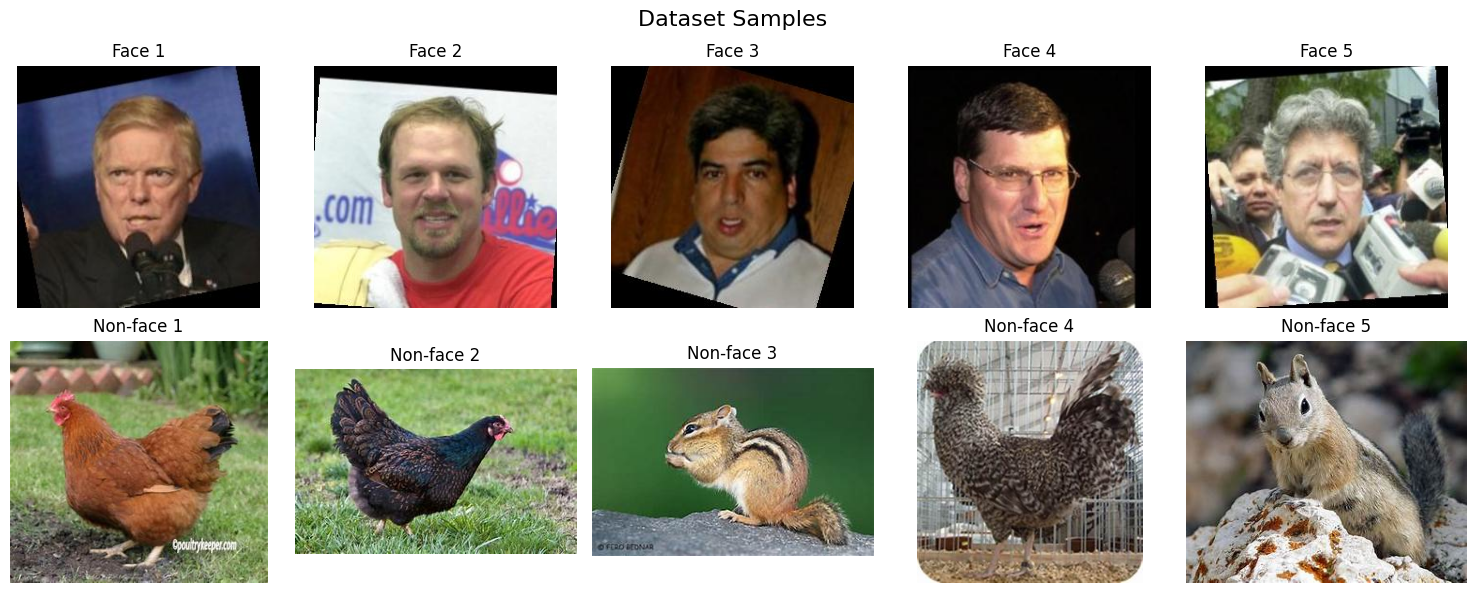

In [9]:
# 1c. VISUALISEER VOORBEELDEN

import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import random

def load_random_images(directory, n=5, extensions=('.jpg', '.png', '.jpeg')):
    """Laad n random afbeeldingen uit een directory"""
    all_images = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(extensions):
                all_images.append(os.path.join(root, file))

    selected = random.sample(all_images, min(n, len(all_images)))
    images = []

    for img_path in selected:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)

    return images

# Laad voorbeelden
lfw_samples = load_random_images('/content/lfw_data/', n=5)
coco_samples = load_random_images('/content/animals_data/', n=5)

# Visualiseer
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Dataset Samples', fontsize=16)

# LFW Gezichten
for i, img in enumerate(lfw_samples):
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Face {i+1}')
    axes[0, i].axis('off')

# COCO Niet-gezichten
for i, img in enumerate(coco_samples):
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Non-face {i+1}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()



In [10]:
# 1d. Laad alle gezichten
X_faces = []
for root, dirs, files in os.walk('/content/lfw_data/'):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (64, 64))
                X_faces.append(img)
X_faces = np.array(X_faces)
print(f"Gezichten geladen: {len(X_faces)}")

# Laad alle niet-gezichten
X_non_faces = []
for root, dirs, files in os.walk('/content/animals_data/'):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (64, 64))
                X_non_faces.append(img)
X_non_faces = np.array(X_non_faces)
print(f"Niet-gezichten geladen: {len(X_non_faces)}")


Gezichten geladen: 13233
Niet-gezichten geladen: 26179


In [11]:
# 1e. Faces en non-faces samenvoegen + 1(faces)/0(non-faces) array maken
X = np.concatenate([X_faces, X_non_faces])
y = np.concatenate([np.ones(len(X_faces)), np.zeros(len(X_non_faces))])


In [ ]:
# 1f. Shuffel + Normaliseren

In [12]:
# alle afbeeldingen en labels zijn momenteel gesorteerd -> shuffle toepassen:
from sklearn.utils import shuffle
X, y = shuffle(X, y, random_state=0)

In [13]:
# Normaliseren van de pixel waarden (alle waardes omzetten naar 0 en 1), voer deze cel maar 1 keer uit!!
X = X.astype('float32') / 255.0
print(f"Min: {X.min()}, Max: {X.max()}")

Min: 0.0, Max: 1.0


In [ ]:
## Stap 2: Train een CNN voor binaire classificatie

In [ ]:
# 2a. Split in test, val en train set

In [14]:
from sklearn.model_selection import train_test_split

# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training: {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

Training: 27588 samples
Validation: 5912 samples
Test: 5912 samples


In [ ]:
# 2b. Bouwen + compile van CNN model

In [15]:
from tensorflow import keras
from tensorflow.keras import layers

# Model bouwen
inputs = keras.Input(shape=(64, 64, 3))

x = layers.Conv2D(32, 3, activation='relu')(inputs)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.Dropout(0.3)(x)

x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,881 (948.75 KB)

 Trainable params: 242,881 (948.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [16]:
# 2c. Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')
]

In [ ]:
# 2d. Trainen
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/5
863/863 ━━━━━━━━━━━━━━━━━━━━ 217s 252ms/step - accuracy: 0.9962 - loss: 0.0106 - val_accuracy: 0.9973 - val_loss: 0.0093
Epoch 2/5
862/863 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9974 - loss: 0.0080

863/863 ━━━━━━━━━━━━━━━━━━━━ 260s 250ms/step - accuracy: 0.9980 - loss: 0.0068 - val_accuracy: 0.9993 - val_loss: 0.0041
Epoch 3/5
863/863 ━━━━━━━━━━━━━━━━━━━━ 260s 248ms/step - accuracy: 0.9974 - loss: 0.0074 - val_accuracy: 0.9988 - val_loss: 0.0045
Epoch 4/5
863/863 ━━━━━━━━━━━━━━━━━━━━ 262s 248ms/step - accuracy: 0.9981 - loss: 0.0057 - val_accuracy: 0.9981 - val_loss: 0.0087
Epoch 5/5
863/863 ━━━━━━━━━━━━━━━━━━━━ 215s 249ms/step - accuracy: 0.9986 - loss: 0.0043 - val_accuracy: 0.9978 - val_loss: 0.0086


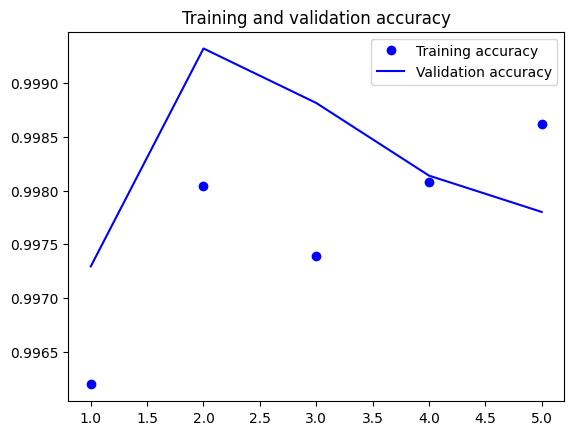

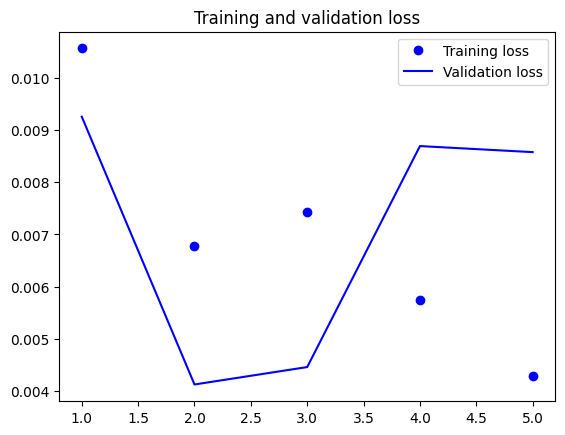

In [ ]:
# 2d. Plotten accuracy + loss
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

# Plot accuracy
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()

# Plot loss
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()

In [ ]:
# Test model op test set
test_model = keras.models.load_model(
    'best_model.h5'
)

test_loss, test_acc = test_model.evaluate(X_test,y_test)

print(f"Test accuracy: {test_acc:.3f}")

185/185 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.9986 - loss: 0.0035
Test accuracy: 0.999


In [ ]:
## Stap 3: Sliding window detectie

In [17]:
# Sliding window functie
def sliding_window(image, window_size, step_size):
    """
    Schuif een window over een afbeelding

    image: de afbeelding waar we overheen gaan
    window_size: grootte van het vierkante window (64)
    step_size: hoeveel pixels we verschuiven (16)
    """

    # Loop van boven naar beneden (y-richting)
    for y in range(0, image.shape[0] - window_size, step_size):

        # Loop van links naar rechts (x-richting)
        for x in range(0, image.shape[1] - window_size, step_size):

            # Knip dit stukje uit de afbeelding
            window = image[y:y+window_size, x:x+window_size]

            # Geef positie (x,y) en het window stukje terug
            yield (x, y, window)

In [18]:
# Test met een voorbeeldafbeelding
test_img = image = image = cv2.imread('test_image.jpg')   # Neem een test image
test_img = test_img.astype('uint8')

window_size = 64
step_size = 8

count = 0
for (x, y, window) in sliding_window(test_img, window_size, step_size):
    count += 1

print(f"Aantal windows: {count}")
# print(f"Window grootte: {window.shape}")

AttributeError: 'NoneType' object has no attribute 'astype'

In [19]:
def image_pyramid(image, scale=0.8, min_size=(64, 64)):
    """
    Maak verschillende schalen van dezelfde afbeelding

    image: originele afbeelding
    scale: hoeveel kleiner elke volgende versie wordt (0.8 = 80% van vorige)
    min_size: stop als afbeelding kleiner wordt dan dit
    """

    # Level 0: originele afbeelding
    yield image

    # Maak steeds kleinere versies
    while True:
        # Bereken nieuwe grootte (80% van huidige)
        h = int(image.shape[0] * scale)
        w = int(image.shape[1] * scale)

        # Stop als te klein
        if h < min_size[0] or w < min_size[1]:
            break

        # Resize afbeelding
        image = cv2.resize(image, (w, h))

        # Geef deze versie terug
        yield image

In [20]:
def detect_faces(image, model, window_size=64, step_size=16, threshold=0.8):
    """
    Detecteer gezichten in een afbeelding met sliding window

    Args:
        image: input afbeelding (RGB)
        model: getraind model
        window_size: grootte van detectie window
        step_size: stap grootte voor sliding
        threshold: minimum confidence voor detectie

    Returns:
        detections: lijst met [x, y, w, h, confidence]
    """
    detections = []

    # Loop door verschillende schalen
    for scale_idx, resized in enumerate(image_pyramid(image)):
        scale_factor = image.shape[0] / resized.shape[0]

        # Slide window over deze schaal
        for (x, y, window) in sliding_window(resized, window_size, step_size):

            # Check grootte
            if window.shape[0] != window_size or window.shape[1] != window_size:
                continue

            # Normaliseer en voorspel
            window_norm = window.astype('float32') / 255.0
            window_input = np.expand_dims(window_norm, axis=0)

            pred = model.predict(window_input, verbose=0)[0][0]

            # Als confidence hoog genoeg
            if pred > threshold:
                # Schaal coordinaten terug naar originele afbeelding
                x1 = int(x * scale_factor)
                y1 = int(y * scale_factor)
                x2 = int((x + window_size) * scale_factor)
                y2 = int((y + window_size) * scale_factor)

                detections.append({
                    'box': (x1, y1, x2, y2),
                    'confidence': float(pred)
                })

    return detections


In [ ]:
# Stap 4: Bounding boxes tekenen

In [33]:
import cv2
import matplotlib.pyplot as plt

# Afbeelding laden
image = cv2.imread('test_image_2.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# # Gezichten detecteren
# detections = detect_faces(image_rgb, test_model)

# # Afbeelding kopie
# output_image = image_rgb.copy()

# # Door detections loopen
# for detection in detections:
#     x1, y1, x2, y2 = detection['box']
#     confidence = detection['confidence']

#     # CVrectangle
#     cv2.rectangle(output_image, (x1, y1), (x2, y2),
#                   color=(0, 255, 0), thickness=2)

#     # CVputText
#     label = f"{confidence:.2f}"
#     cv2.putText(output_image, label,
#                 (x1, y1 - 10),
#                 fontFace=cv2.FONT_HERSHEY_SIMPLEX,
#                 fontScale=0.8,
#                 color=(0, 255, 0),
#                 thickness=2)

# # Weergeven
# plt.figure(figsize=(12, 8))
# plt.imshow(output_image)
# plt.axis('off')
# plt.title(f"Detectie: {len(detections)} gezicht(en)")
# plt.show()

In [ ]:
## Stap 5: Non-Maximum Suppression (NMS)

In [ ]:
# 5a. Intersection over Union

In [21]:
def compute_iou(box1, box2):
    """
    Bereken overlap tussen twee boxes

    box1, box2: (x1, y1, x2, y2)

    Returns: IoU waarde tussen 0 en 1
    """
    # Vind overlap rechthoek
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    # Bereken overlap oppervlakte
    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    # Bereken totale oppervlakte van beide boxes
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    # IoU = overlap / totaal
    return intersection / union if union > 0 else 0


In [ ]:
# 5b. Non Maximum Supression

In [22]:
def non_max_suppression(detections, iou_threshold=0.5):
    """
    Verwijder overlappende boxes

    detections: lijst met {'box': (x1,y1,x2,y2), 'confidence': float}
    iou_threshold: maximale toegestane overlap (0.5 = 50%)

    Returns: gefilterde lijst
    """
    if len(detections) == 0:
        return []

    # Sorteer op confidence (hoogste eerst)
    detections = sorted(detections, key=lambda x: x['confidence'], reverse=True)

    keep = []

    while len(detections) > 0:
        # Neem beste detectie
        best = detections.pop(0)
        keep.append(best)

        # Verwijder alle detecties die te veel overlappen met beste
        detections = [
            d for d in detections
            if compute_iou(best['box'], d['box']) < iou_threshold
        ]

    return keep

Voor NMS: 6 detecties
Na NMS: 5 detecties


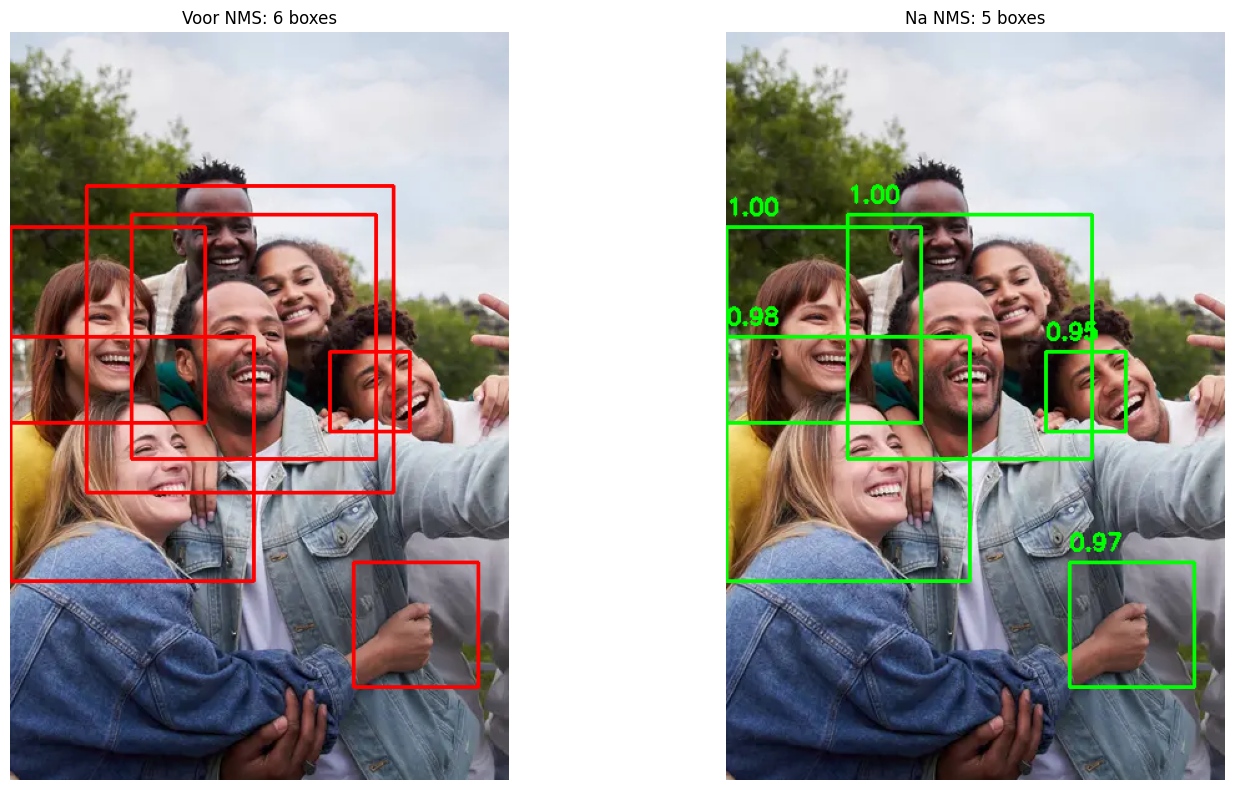

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Detecteer gezichten (voor NMS)
detections_before = detect_faces(image_rgb, test_model, threshold=0.8)

# Pas NMS toe
detections_after = non_max_suppression(detections_before, iou_threshold=0.5)

print(f"Voor NMS: {len(detections_before)} detecties")
print(f"Na NMS: {len(detections_after)} detecties")

# Teken beide
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Voor NMS
img_before = image_rgb.copy()
for det in detections_before:
    x1, y1, x2, y2 = det['box']
    cv2.rectangle(img_before, (x1, y1), (x2, y2), (255, 0, 0), 2)

axes[0].imshow(img_before)
axes[0].set_title(f'Voor NMS: {len(detections_before)} boxes')
axes[0].axis('off')

# Na NMS
img_after = image_rgb.copy()
for det in detections_after:
    x1, y1, x2, y2 = det['box']
    conf = det['confidence']
    cv2.rectangle(img_after, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img_after, f"{conf:.2f}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

axes[1].imshow(img_after)
axes[1].set_title(f'Na NMS: {len(detections_after)} boxes')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Data Augmentation

In [35]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2)

])

In [36]:
# model met data augmentation
inputs = keras.Input(shape=(64, 64, 3))

x = data_augmentation(inputs)
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.Dropout(0.3)(x)

x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_aug = keras.Model(inputs=inputs, outputs=outputs)

model_aug.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,881 (948.75 KB)

 Trainable params: 242,881 (948.75 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model_aug.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [38]:
callbacks_aug = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model_aug.keras', monitor='val_accuracy', save_best_only=True, mode='max')
]

In [40]:
# 2d. Trainen
history_aug = model_aug.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=callbacks_aug
)

Epoch 1/10
863/863 ━━━━━━━━━━━━━━━━━━━━ 246s 285ms/step - accuracy: 0.9945 - loss: 0.0178 - val_accuracy: 0.9981 - val_loss: 0.0052
Epoch 2/10
863/863 ━━━━━━━━━━━━━━━━━━━━ 251s 290ms/step - accuracy: 0.9955 - loss: 0.0139 - val_accuracy: 0.9964 - val_loss: 0.0120
Epoch 3/10
863/863 ━━━━━━━━━━━━━━━━━━━━ 252s 292ms/step - accuracy: 0.9960 - loss: 0.0126 - val_accuracy: 0.9981 - val_loss: 0.0046
Epoch 4/10
863/863 ━━━━━━━━━━━━━━━━━━━━ 252s 292ms/step - accuracy: 0.9972 - loss: 0.0091 - val_accuracy: 0.9973 - val_loss: 0.0097
Epoch 5/10
863/863 ━━━━━━━━━━━━━━━━━━━━ 251s 291ms/step - accuracy: 0.9961 - loss: 0.0118 - val_accuracy: 0.9975 - val_loss: 0.0095
Epoch 6/10
863/863 ━━━━━━━━━━━━━━━━━━━━ 251s 291ms/step - accuracy: 0.9969 - loss: 0.0099 - val_accuracy: 0.9975 - val_loss: 0.0068
Epoch 7/10
863/863 ━━━━━━━━━━━━━━━━━━━━ 255s 284ms/step - accuracy: 0.9963 - loss: 0.0107 - val_accuracy: 0.9990 - val_loss: 0.0051
Epoch 8/10
863/863 ━━━━━━━━━━━━━━━━━━━━ 245s 284ms/step - accuracy: 0.9968 -

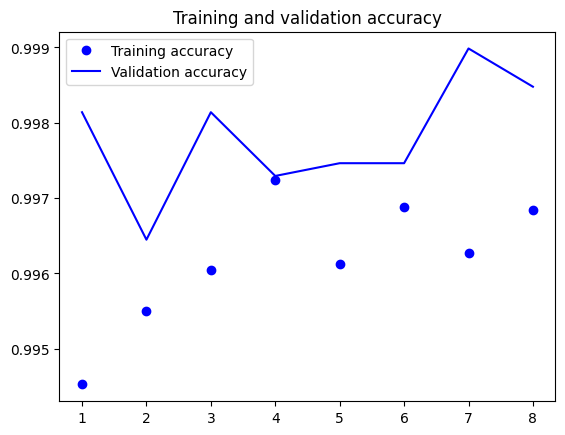

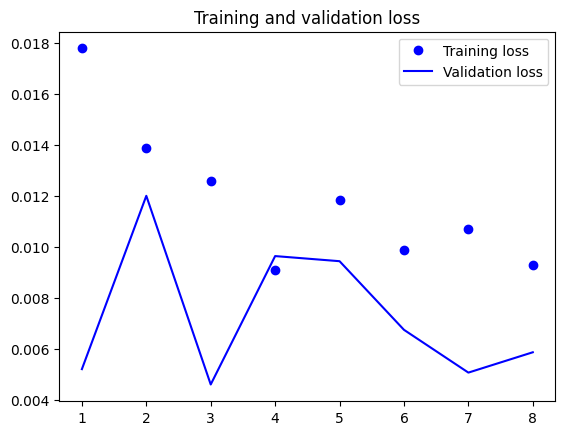

In [41]:
# 2d. Plotten accuracy + loss
import matplotlib.pyplot as plt

accuracy = history_aug.history["accuracy"]
val_accuracy = history_aug.history["val_accuracy"]
loss = history_aug.history["loss"]
val_loss = history_aug.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

# Plot accuracy
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()

# Plot loss
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()

In [42]:
# Test model op test set
test_model_aug = keras.models.load_model(
    'best_model_aug.keras'
)

test_loss, test_acc = test_model_aug.evaluate(X_test,y_test)

print(f"Test accuracy: {test_acc:.3f}")

185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.9985 - loss: 0.0047
Test accuracy: 0.998


Voor NMS: 9 detecties
Na NMS: 8 detecties


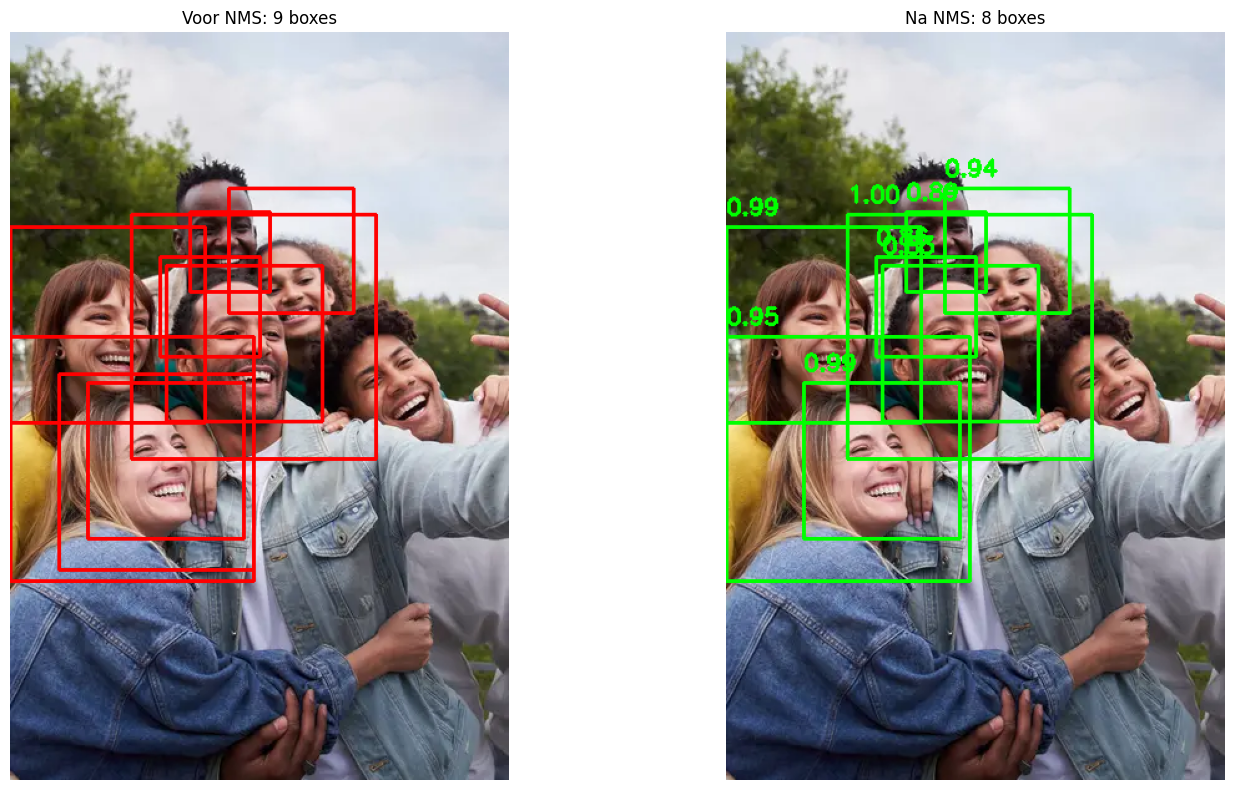

In [43]:
import matplotlib.pyplot as plt
import cv2

# Detecteer gezichten (voor NMS)
detections_before = detect_faces(image_rgb, test_model_aug, threshold=0.8)

# Pas NMS toe
detections_after = non_max_suppression(detections_before, iou_threshold=0.5)

print(f"Voor NMS: {len(detections_before)} detecties")
print(f"Na NMS: {len(detections_after)} detecties")

# Teken beide
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Voor NMS
img_before = image_rgb.copy()
for det in detections_before:
    x1, y1, x2, y2 = det['box']
    cv2.rectangle(img_before, (x1, y1), (x2, y2), (255, 0, 0), 2)

axes[0].imshow(img_before)
axes[0].set_title(f'Voor NMS: {len(detections_before)} boxes')
axes[0].axis('off')

# Na NMS
img_after = image_rgb.copy()
for det in detections_after:
    x1, y1, x2, y2 = det['box']
    conf = det['confidence']
    cv2.rectangle(img_after, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img_after, f"{conf:.2f}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

axes[1].imshow(img_after)
axes[1].set_title(f'Na NMS: {len(detections_after)} boxes')
axes[1].axis('off')

plt.tight_layout()
plt.show()